# Operating Characteristics of the Non-Paired Bayes Procedure

A Bayesian *model* doesn't have a Type-I error, but the moment we wrap it in a **decision rule** (here the Savage–Dickey BF threshold `BF₁₀ > 3` ⇒ reject H₀, `BF₁₀ < 1/3` ⇒ accept H₀, otherwise inconclusive) we get a function from data → decision whose frequentist operating characteristics are well-defined. Evaluating those characteristics by simulation is the statistically correct way to characterise the procedure (*calibrated Bayes*; Rubin 1984, Little 2006).

Four diagnostics are produced below. Together they replace a single “power curve” (which would be the wrong object here because Bayesian decisions admit an *inconclusive* zone):

1. **Three-way OC curves** — `P(reject H₀)`, `P(accept H₀)`, `P(inconclusive)` as functions of the true effect `Δ = p_A − p_B`, at a fixed baseline `p_B`.
2. **Null-decision (Type-I analogue) curve** — `P(reject H₀ | Δ = 0)` swept over the baseline rate `p_B` (BFs on proportions are not translation-invariant in `p`, so this matters).
3. **Credible-interval coverage** — frequentist coverage of the 95 % equal-tailed interval on `Δ` as a function of true `Δ`.
4. **Sequential stopping-time distribution (ESS)** — expected and quantile sample size at which the *sequential* BF rule stops, by true `Δ`.

All simulations re-use the public API of `NonPairedBayesPropTest` and `SequentialNonPairedBayesPropTest`, so any change to the procedure (prior, BF thresholds, ROPE width, batch size, …) is reflected end-to-end.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bayesprop.utils.operation_characteristics import (
    grid_fixed_n,
    matched_calibration_alpha,
    simulate_sequential,
    wilson_band,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# ---- analysis prior (must match how the procedure would be deployed) -----
ALPHA0, BETA0 = 1.0, 1.0

# ---- decision rule (Savage–Dickey BF on the point null Δ = 0) -------------
BF_UPPER, BF_LOWER = 3.0, 1.0 / 3.0  # “moderate evidence” thresholds

# ---- simulation budget (tune for speed/accuracy trade-off) ---------------
M_FIXED = 400      # replicates per grid point for plots 1–3
M_SEQ = 80         # replicates per grid point for the sequential plot
N_PER_ARM = 200    # fixed-n sample size for plots 1–3
N_SAMPLES_MC = 4000  # posterior MC draws per replicate (for CI coverage)

RNG_SEED = 20260514

Matplotlib is building the font cache; this may take a moment.


## Simulation harness

Every step goes through the existing public API — this notebook doubles as an end‑to‑end integration test of the codebase. For each replicate we:

1. generate a dataset with `simulate_nonpaired_scores` (the codebase's own DGP),
2. fit the model via `NonPairedBayesPropTest.fit`, which produces the Beta posteriors, the Monte‑Carlo draws of `Δ = θ_A − θ_B`, and the 95 % credible interval (`bb.summary.ci_95`),
3. compute the Savage–Dickey BF on `Δ = 0` via `bb.savage_dickey_test()`,
4. classify the result via `classify_bf(bf10, BF_UPPER, BF_LOWER)` — the *same* helper that `SequentialNonPairedBayesPropTest` uses internally for its stopping rule, so the two procedures are guaranteed to agree on the decision boundaries:

   * **reject** — `BF₁₀ ≥ BF_UPPER`
   * **accept** — `BF₁₀ ≤ BF_LOWER`
   * **inconclusive** — otherwise

Because the harness only consumes public symbols (`fit`, `savage_dickey_test`, `summary`, `classify_bf`, `update`, `stopped`, `stop_reason`), any regression in those will surface as a visible distortion of the OC plots (coverage drifting off 0.95, the null curve crossing 0.05, asymmetric power, censoring spike).

In [2]:
# Common keyword arguments forwarded to every call into the
# operation_characteristics module — keeps the orchestration cells
# below short and ensures the fixed-n and sequential analyses share
# the same prior, BF thresholds, and posterior-MC budget.
FIXED_N_CONFIG: dict[str, float] = dict(
    alpha0=ALPHA0,
    beta0=BETA0,
    bf_upper=BF_UPPER,
    bf_lower=BF_LOWER,
    n_samples_mc=N_SAMPLES_MC,
)
SEQ_CONFIG: dict[str, float] = dict(
    alpha0=ALPHA0,
    beta0=BETA0,
    bf_upper=BF_UPPER,
    bf_lower=BF_LOWER,
)

## Plot 1 — Three-way operating-characteristic curves (with frequentist baseline)

We fix `p_B = 0.60` and sweep `Δ = p_A − p_B` over `[−0.25, +0.25]`. For each `Δ` we plot the three Bayesian decision probabilities. The red `P(reject H₀)` curve is the analogue of frequentist power; the green `P(accept H₀)` curve is something a frequentist test fundamentally cannot give you; and the grey curve is the inconclusive zone.

As a sanity-check baseline we run **Fisher's exact test** on the *same* simulated data via `fisher_exact_nonpaired_test` and plot its `P(reject H₀)` curve twice:

- At the conventional **α = 0.05** cutoff (dotted line).
- At a **matched-calibration α** chosen so the frequentist Type-I rate at `Δ = 0` equals the Bayes Type-I rate empirically (dashed line). This is the fairest like-for-like power comparison — both procedures have the same false-positive rate at the null, so any difference further out reflects pure detection efficiency.

If the Bayes procedure is well-calibrated, the matched-α frequentist curve should lie *close* to the Bayes reject curve in the body of the alternative, with the Bayes rule slightly more powerful in the inconclusive transition zone (because it can afford to be while still spending the same Type-I budget).

In [3]:
p_B_fixed = 0.60
delta_grid = np.linspace(-0.25, 0.25, 17)
grid_oc = [(round(p_B_fixed + d, 4), p_B_fixed) for d in delta_grid if 0.0 <= p_B_fixed + d <= 1.0]

df_oc, pvals_oc = grid_fixed_n(
    grid_oc, n=N_PER_ARM, n_sim=M_FIXED, seed=RNG_SEED, track_ci=True, **FIXED_N_CONFIG
)

# Pick the Fisher α whose Type-I rate matches the Bayes rule's at Δ = 0.
# This is the fairest like-for-like calibration.
idx_null = int(np.argmin(np.abs(df_oc["delta"].to_numpy())))
bayes_type1 = float(df_oc.iloc[idx_null]["reject"])
alpha_matched = matched_calibration_alpha(pvals_oc, bayes_type1, idx_null)
df_oc["freq_reject_matched"] = (pvals_oc < alpha_matched).mean(axis=1)
df_oc["freq_reject_0p05"] = (pvals_oc < 0.05).mean(axis=1)

print(f"Bayes Type-I rate at Δ=0: {bayes_type1:.3f}  →  matched-α for Fisher: {alpha_matched:.4f}")
df_oc[["delta", "reject", "freq_reject_matched", "freq_reject_0p05", "ci_coverage"]].head()

Bayes Type-I rate at Δ=0: 0.010  →  matched-α for Fisher: 0.0159


,delta,reject,freq_reject_matched,freq_reject_0p05,ci_coverage
0,-0.2500,0.9825,0.9825,0.9975,0.9375
1,-0.2188,0.9625,0.9650,0.9875,0.9375
2,-0.1875,0.8725,0.8725,0.9400,0.9525
3,-0.1562,0.6950,0.6975,0.8200,0.9550
4,-0.1250,0.4725,0.4850,0.6750,0.9150


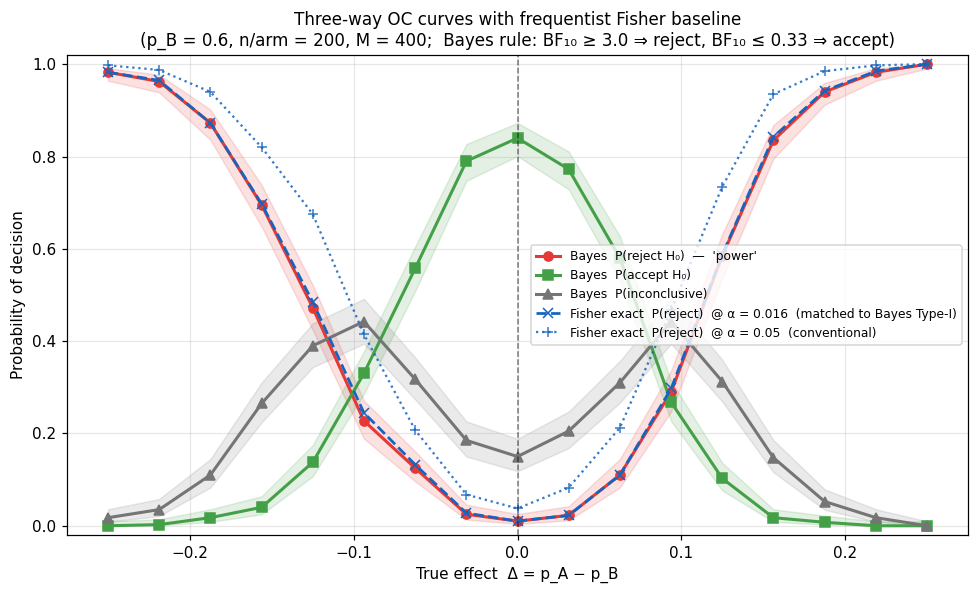

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# Wilson 95 % Monte-Carlo bands on the three Bayes rates, so plot
# uncertainty is visible — especially near the tails where the rates
# are small and Wald bands would collapse or escape [0, 1].
delta_x = df_oc["delta"].to_numpy()
for col, color in (("reject", "#E53935"), ("accept", "#43A047"), ("inconclusive", "#757575")):
    lo, hi = wilson_band(df_oc[col].to_numpy(), n_sim=M_FIXED)
    ax.fill_between(delta_x, lo, hi, color=color, alpha=0.15)

# Bayesian three-way OC curves
ax.plot(df_oc["delta"], df_oc["reject"], marker="o", color="#E53935", lw=2,
        label="Bayes  P(reject H₀)  —  'power'")
ax.plot(df_oc["delta"], df_oc["accept"], marker="s", color="#43A047", lw=2,
        label="Bayes  P(accept H₀)")
ax.plot(df_oc["delta"], df_oc["inconclusive"], marker="^", color="#757575", lw=2,
        label="Bayes  P(inconclusive)")

# Frequentist baseline: Fisher's exact test, two curves
ax.plot(df_oc["delta"], df_oc["freq_reject_matched"],
        marker="x", ls="--", color="#1565C0", lw=1.8,
        label=f"Fisher exact  P(reject)  @ α = {alpha_matched:.3f}  (matched to Bayes Type-I)")
ax.plot(df_oc["delta"], df_oc["freq_reject_0p05"],
        marker="+", ls=":", color="#1565C0", lw=1.5, alpha=0.85,
        label="Fisher exact  P(reject)  @ α = 0.05  (conventional)")

ax.axvline(0.0, ls="--", color="black", lw=1, alpha=0.5)
ax.set_xlabel("True effect  Δ = p_A − p_B")
ax.set_ylabel("Probability of decision")
ax.set_ylim(-0.02, 1.02)
ax.set_title(
    f"Three-way OC curves with frequentist Fisher baseline\n"
    f"(p_B = {p_B_fixed}, n/arm = {N_PER_ARM}, M = {M_FIXED};  "
    f"Bayes rule: BF₁₀ ≥ {BF_UPPER} ⇒ reject, BF₁₀ ≤ {BF_LOWER:.2f} ⇒ accept)",
    fontsize=11,
)
ax.legend(loc="center right", fontsize=8)
plt.tight_layout()
plt.show()

## Plot 2 — Null-decision rate vs baseline `p_B`

The Beta–Bernoulli BF is **not** translation-invariant in `p`: the same `Δ = 0` looks different near `p = 0.5` vs near the boundary. We sweep `p_A = p_B` over `[0.05, 0.95]` and report `P(reject H₀ | Δ = 0)`, the analogue of a Type-I error rate, plus the rate at which the procedure decisively accepts H₀.

In [5]:
p_grid = np.linspace(0.05, 0.95, 19)
grid_null = [(round(p, 4), round(p, 4)) for p in p_grid]
df_null, pvals_null = grid_fixed_n(
    grid_null,
    n=N_PER_ARM,
    n_sim=M_FIXED,
    seed=RNG_SEED + 1,
    track_ci=False,
    **FIXED_N_CONFIG,
)
# Frequentist Type-I curve at α = 0.05 for comparison
df_null["freq_reject_0p05"] = (pvals_null < 0.05).mean(axis=1)
df_null[["p_B", "reject", "freq_reject_0p05", "accept"]].head()

,p_B,reject,freq_reject_0p05,accept
0,0.05,0.0050,0.0325,0.9525
1,0.10,0.0075,0.0275,0.9300
2,0.15,0.0125,0.0425,0.8925
3,0.20,0.0125,0.0325,0.8750
4,0.25,0.0075,0.0400,0.8300


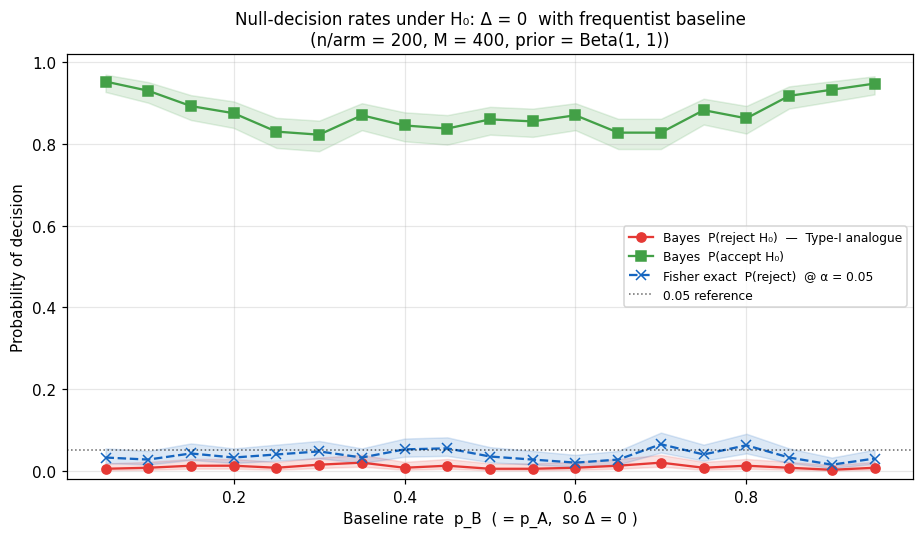

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5))

# Wilson 95 % MC bands on the Bayes + Fisher rates. The Type-I curve
# is the most sensitive of all OC quantities to MC noise, so the band
# is most informative here.
p_B_x = df_null["p_B"].to_numpy()
for col, color in (
    ("reject", "#E53935"),
    ("accept", "#43A047"),
    ("freq_reject_0p05", "#1565C0"),
):
    lo, hi = wilson_band(df_null[col].to_numpy(), n_sim=M_FIXED)
    ax.fill_between(p_B_x, lo, hi, color=color, alpha=0.15)

ax.plot(df_null["p_B"], df_null["reject"], marker="o", color="#E53935",
        label="Bayes  P(reject H₀)  —  Type-I analogue")
ax.plot(df_null["p_B"], df_null["accept"], marker="s", color="#43A047",
        label="Bayes  P(accept H₀)")
ax.plot(df_null["p_B"], df_null["freq_reject_0p05"], marker="x", ls="--", color="#1565C0",
        label="Fisher exact  P(reject)  @ α = 0.05")
ax.axhline(0.05, ls=":", color="black", lw=1, alpha=0.6, label="0.05 reference")
ax.set_xlabel("Baseline rate  p_B  ( = p_A,  so Δ = 0 )")
ax.set_ylabel("Probability of decision")
ax.set_ylim(-0.02, 1.02)
ax.set_title(
    f"Null-decision rates under H₀: Δ = 0  with frequentist baseline\n"
    f"(n/arm = {N_PER_ARM}, M = {M_FIXED}, prior = Beta({ALPHA0:.0f}, {BETA0:.0f}))",
    fontsize=11,
)
ax.legend(loc="center right", fontsize=8)
plt.tight_layout()
plt.show()

## Plot 3 — Credible-interval coverage of `Δ`

Frequentist coverage of a Bayesian interval is the cleanest “is my posterior honest?” check. We reuse the `Δ`-sweep grid from plot 1 and report the fraction of replicates in which the 95 % equal-tailed posterior interval on `Δ` contained the true `Δ`. With a flat prior and modest `n`, coverage should hover near the nominal 0.95 across most of the grid; small deviations at the boundaries (`p_A` near 0 or 1) are expected.

We add a Monte-Carlo Wilson confidence band so the plot shows whether deviations from 0.95 are real or simulation noise.

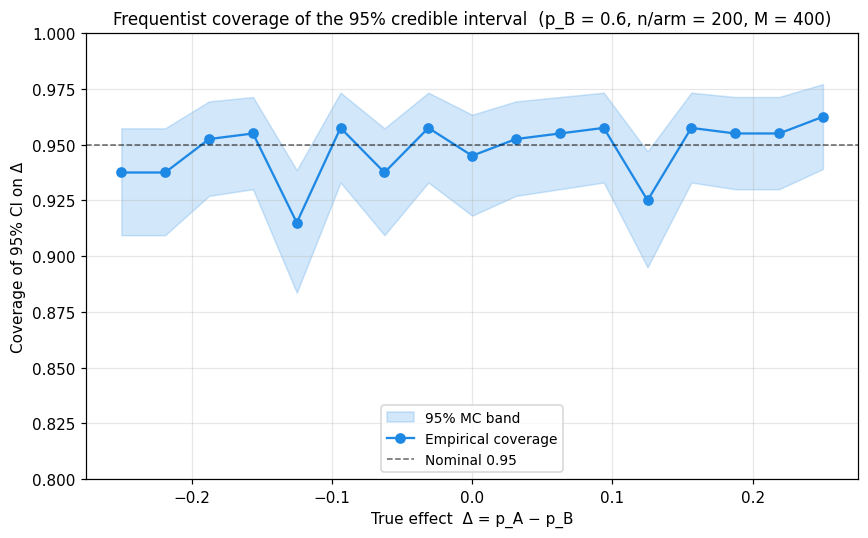

In [7]:
lo, hi = wilson_band(df_oc["ci_coverage"].to_numpy(), n_sim=M_FIXED)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(df_oc["delta"], lo, hi, color="#1E88E5", alpha=0.2, label="95% MC band")
ax.plot(df_oc["delta"], df_oc["ci_coverage"], marker="o", color="#1E88E5", label="Empirical coverage")
ax.axhline(0.95, ls="--", color="black", lw=1, alpha=0.6, label="Nominal 0.95")
ax.set_xlabel("True effect  Δ = p_A − p_B")
ax.set_ylabel("Coverage of 95% CI on Δ")
ax.set_ylim(0.80, 1.0)
ax.set_title(
    f"Frequentist coverage of the 95% credible interval  (p_B = {p_B_fixed}, n/arm = {N_PER_ARM}, M = {M_FIXED})",
    fontsize=11,
)
ax.legend(loc="lower center", fontsize=9)
plt.tight_layout()
plt.show()

## Plot 4 — Sequential stopping-time distribution (ESS)

When the procedure is allowed to stop early via `SequentialNonPairedBayesPropTest`, the right operating characteristic is the **distribution of the stopping sample size** under each true `Δ`. We re-run the whole sequential decision rule (batches of `BATCH_SIZE`, `n_min` warm-up, `n_max` hard cap, the same BF thresholds as above) and record the per-arm sample size at which it stops. Trials that hit `n_max` are *right-censored* and shown separately because the mean of the stopping time would otherwise be biased downward.

The plot shows the median, IQR, and 90 % interval of the stopping time, plus the fraction of trials that hit the cap.

In [8]:
# Sequential design parameters — forwarded to simulate_sequential().
BATCH_SIZE = 50
N_MIN_SEQ = 50
N_MAX_SEQ = 600

rng_seq = np.random.default_rng(RNG_SEED + 2)
delta_grid_seq = np.linspace(-0.20, 0.20, 11)
rows_seq = []
for d in delta_grid_seq:
    p_A = round(p_B_fixed + d, 4)
    if not 0.0 <= p_A <= 1.0:
        continue
    rows_seq.append(
        simulate_sequential(
            p_A,
            p_B_fixed,
            n_sim=M_SEQ,
            rng=rng_seq,
            n_min=N_MIN_SEQ,
            n_max=N_MAX_SEQ,
            batch_size=BATCH_SIZE,
            **SEQ_CONFIG,
        )
    )
df_seq = pd.DataFrame(rows_seq)
df_seq

,p_A,p_B,delta,median_n,q05,q25,q75,q95,frac_censored,frac_reject,frac_accept
0,0.40,0.6,-0.20,50.0,50.0,50.0,100.0,200.0,0.0000,0.8375,0.1625
1,0.44,0.6,-0.16,100.0,50.0,50.0,100.0,250.0,0.0000,0.8000,0.2000
2,0.48,0.6,-0.12,50.0,50.0,50.0,150.0,252.5,0.0000,0.5000,0.5000
3,0.52,0.6,-0.08,100.0,50.0,50.0,150.0,300.0,0.0125,0.2875,0.7000
4,0.56,0.6,-0.04,50.0,50.0,50.0,100.0,150.0,0.0000,0.0875,0.9125
5,0.60,0.6,0.00,50.0,50.0,50.0,100.0,202.5,0.0000,0.0625,0.9375
6,0.64,0.6,0.04,50.0,50.0,50.0,112.5,350.0,0.0250,0.0875,0.9000
7,0.68,0.6,0.08,50.0,50.0,50.0,100.0,202.5,0.0000,0.2375,0.7625
8,0.72,0.6,0.12,100.0,50.0,50.0,150.0,352.5,0.0125,0.5125,0.4750
9,0.76,0.6,0.16,100.0,50.0,50.0,100.0,200.0,0.0000,0.8125,0.1875


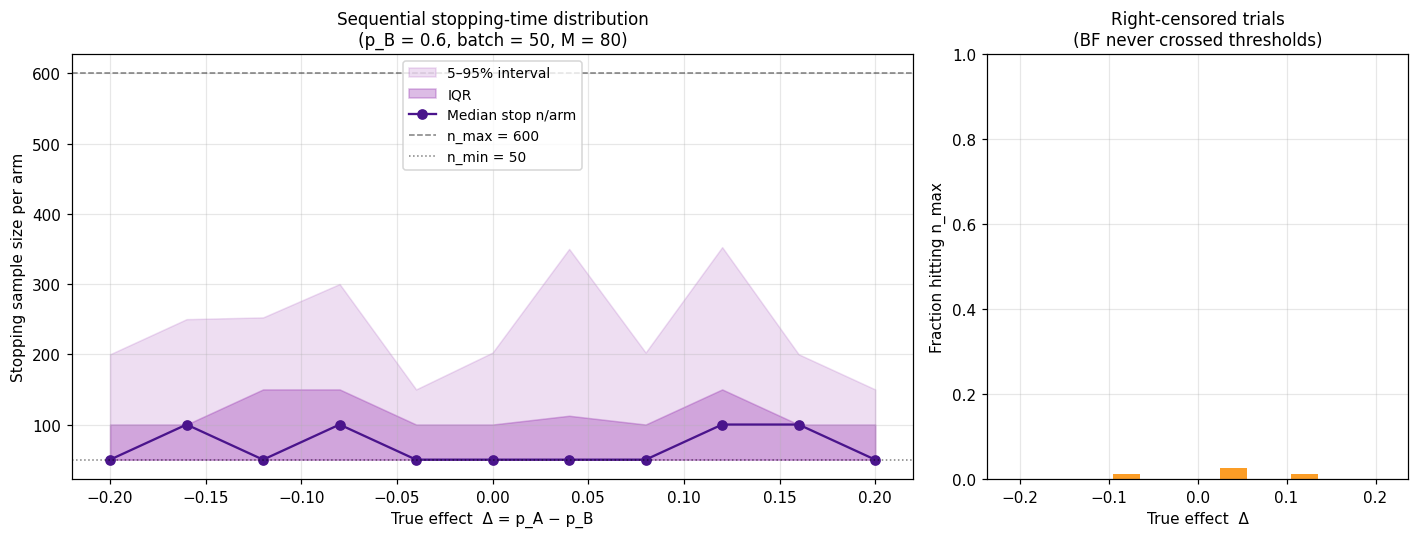

In [9]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})

ax.fill_between(df_seq["delta"], df_seq["q05"], df_seq["q95"], color="#8E24AA", alpha=0.15, label="5–95% interval")
ax.fill_between(df_seq["delta"], df_seq["q25"], df_seq["q75"], color="#8E24AA", alpha=0.30, label="IQR")
ax.plot(df_seq["delta"], df_seq["median_n"], marker="o", color="#4A148C", label="Median stop n/arm")
ax.axhline(N_MAX_SEQ, ls="--", color="black", lw=1, alpha=0.5, label=f"n_max = {N_MAX_SEQ}")
ax.axhline(N_MIN_SEQ, ls=":", color="black", lw=1, alpha=0.5, label=f"n_min = {N_MIN_SEQ}")
ax.set_xlabel("True effect  Δ = p_A − p_B")
ax.set_ylabel("Stopping sample size per arm")
ax.set_title(
    f"Sequential stopping-time distribution\n(p_B = {p_B_fixed}, batch = {BATCH_SIZE}, M = {M_SEQ})",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper center")

ax2.bar(df_seq["delta"], df_seq["frac_censored"], width=0.03, color="#FB8C00", alpha=0.85)
ax2.set_xlabel("True effect  Δ")
ax2.set_ylabel("Fraction hitting n_max")
ax2.set_ylim(0, 1)
ax2.set_title("Right-censored trials\n(BF never crossed thresholds)", fontsize=11)

plt.tight_layout()
plt.show()

## How to read these together

* **Plot 1** is the Bayesian generalisation of a power curve. The grey *inconclusive* band is the procedure honestly saying “not enough data” — not a misclassification.
* **Plot 2** tells you the false-positive rate of the BF rule at the null and how it depends on the baseline rate. With `BF_UPPER = 3` it will typically be a few percent, not the 5 % you'd get from a frequentist test.
* **Plot 3** is a calibration check on the posterior — if coverage drifts well away from 0.95, the prior/likelihood combination is biased for that part of the parameter space.
* **Plot 4** is the design diagnostic for the sequential procedure: it tells you the *realised* sample size you should budget for, and the censoring fraction tells you how often the procedure will hit `n_max` without deciding (i.e. when you need a bigger `n_max` or different thresholds).

To stress-test other configurations, change the constants in the second cell (`BF_UPPER`, `BF_LOWER`, `N_PER_ARM`, `ALPHA0`, `BETA0`, `BATCH_SIZE`, `N_MAX_SEQ`, …) and re-run — the whole notebook is parameter-driven.